# 과제 5, 6 — 활성화 함수 · MLP

## 과제 5. 활성화 함수 정의 · 출력 계산 · 시각화

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 활성화 함수 정의
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.1):
    return np.where(x > 0, x, alpha * x)

# 입력값 생성
x = np.linspace(-5, 5, 200)

# 각 함수 출력 계산
print('x = [-2, -1, 0, 1, 2]')
sample = np.array([-2, -1, 0, 1, 2])
print(f'Sigmoid:     {sigmoid(sample).round(4)}')
print(f'Tanh:        {tanh(sample).round(4)}')
print(f'ReLU:        {relu(sample)}')
print(f'Leaky ReLU:  {leaky_relu(sample)}')

x = [-2, -1, 0, 1, 2]
Sigmoid:     [0.1192 0.2689 0.5    0.7311 0.8808]
Tanh:        [-0.964  -0.7616  0.      0.7616  0.964 ]
ReLU:        [0 0 0 1 2]
Leaky ReLU:  [-0.2 -0.1  0.   1.   2. ]


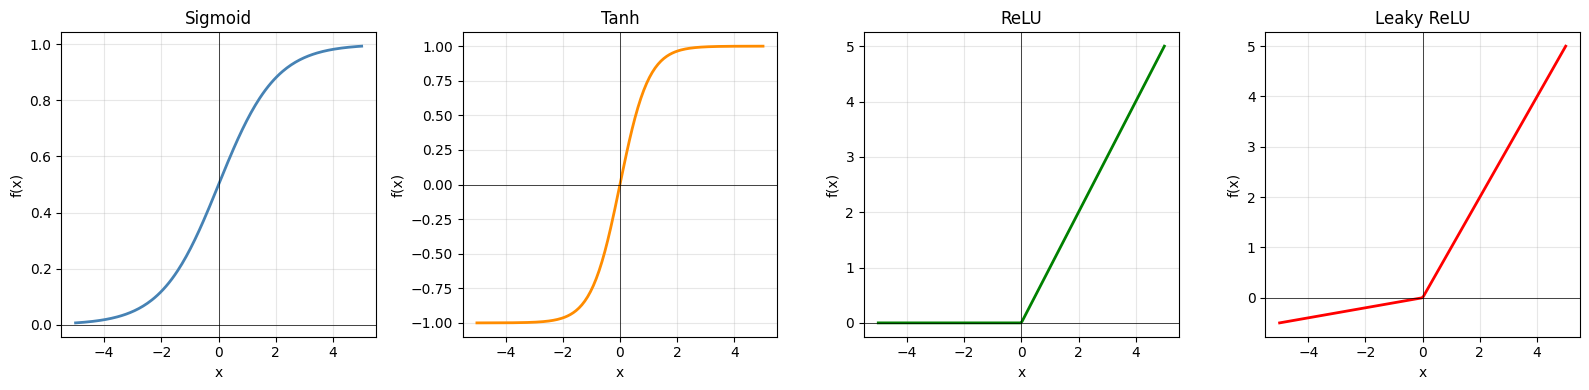

In [7]:
# 시각화
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

functions = [
    ('Sigmoid',    sigmoid(x),      'steelblue'),
    ('Tanh',       tanh(x),         'darkorange'),
    ('ReLU',       relu(x),         'green'),
    ('Leaky ReLU', leaky_relu(x),   'red'),
]

for ax, (name, y, color) in zip(axes, functions):
    ax.plot(x, y, color=color, linewidth=2)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_title(name)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 과제 6. 비선형 데이터셋 MLP 분류

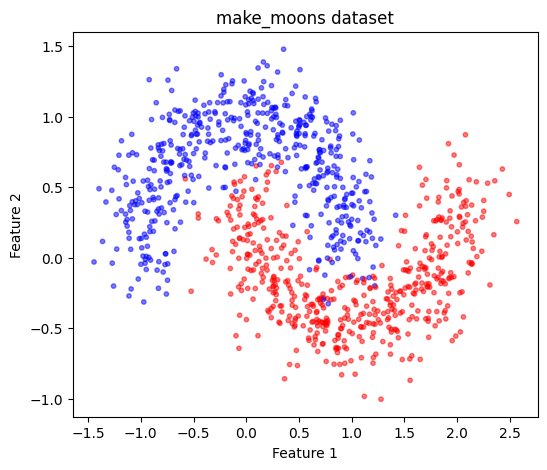

In [8]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 비선형 데이터셋 생성
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# 데이터 시각화
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.5, s=10)
plt.title('make_moons dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [9]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

X_tr = torch.from_numpy(X_train_sc.astype(np.float32))
y_tr = torch.from_numpy(y_train.astype(np.float32)).unsqueeze(1)
X_te = torch.from_numpy(X_test_sc.astype(np.float32))
y_te = torch.from_numpy(y_test.astype(np.float32)).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)

model = nn.Sequential(
    nn.Linear(2, 64),  nn.ReLU(),
    nn.Linear(64, 64), nn.ReLU(),
    nn.Linear(64, 32), nn.ReLU(),
    nn.Linear(32, 1),  nn.Sigmoid()
)

optimizer = optim.Adam(model.parameters())
criterion = nn.BCELoss()

for epoch in range(50):
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        criterion(model(X_batch), y_batch).backward()
        optimizer.step()

model.eval()
with torch.no_grad():
    preds = (model(X_te) >= 0.5).float()
    acc   = (preds == y_te).float().mean().item()
print(f'테스트 정확도: {acc:.4f}')

테스트 정확도: 0.9800


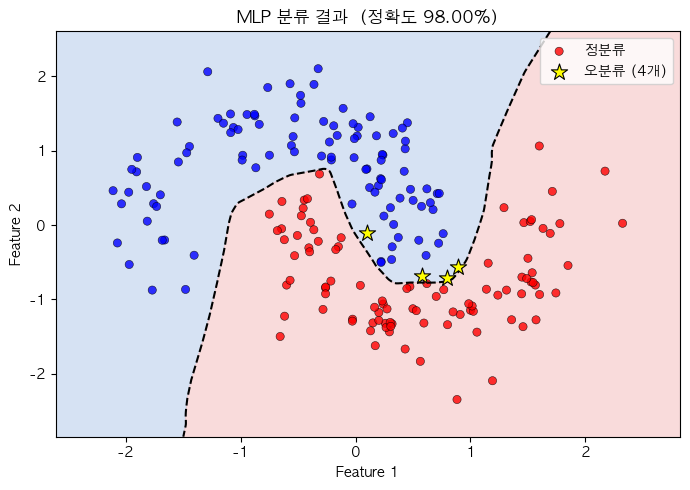

In [10]:
# 분류 결과 시각화
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 결정 경계용 메시 그리드
x_min, x_max = X_test_sc[:, 0].min() - 0.5, X_test_sc[:, 0].max() + 0.5
y_min, y_max = X_test_sc[:, 1].min() - 0.5, X_test_sc[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()].astype(np.float32))

model.eval()
with torch.no_grad():
    Z = model(grid).numpy().reshape(xx.shape)

preds_np  = preds.numpy().flatten()
y_te_np   = y_te.numpy().flatten()
correct   = preds_np == y_te_np

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], colors=['#aec6e8', '#f5b8b8'], alpha=0.5)
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=1.5, linestyles='--')

plt.scatter(X_test_sc[correct, 0],  X_test_sc[correct, 1],
            c=y_te_np[correct], cmap='bwr', edgecolors='k',
            linewidths=0.4, s=35, alpha=0.8, label='정분류')
plt.scatter(X_test_sc[~correct, 0], X_test_sc[~correct, 1],
            c='yellow', edgecolors='black', marker='*',
            s=150, linewidths=0.8, zorder=5, label=f'오분류 ({(~correct).sum()}개)')

plt.title(f'MLP 분류 결과  (정확도 {acc:.2%})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()
